# 01 · Camera Calibration & Frame Extraction

**Goal:** recover the camera intrinsics K from a checkerboard video and
extract frames from the skyward orbital capture into `data/frames/<tree_id>/`.

This notebook wraps OpenCV's calibration — it is **not** from-scratch credit;
the from-scratch geometry lives in `03_two_view_scratch.ipynb`.

In [1]:
# Standard preamble — every notebook seeds np.random.seed(131).
import sys
from pathlib import Path

# Make `src/` importable from the notebooks/ directory.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
np.random.seed(131)

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from src import calibration

CALIB_VIDEO = PROJECT_ROOT / "data" / "calibration" / "checkerboard.mov"
CALIB_OUT = PROJECT_ROOT / "data" / "calibration" / "intrinsics.npz"

## 1. Calibrate from the checkerboard video

Capture a 15–30 sec clip waving a printed checkerboard in front of the
same phone you'll use for the tree (same focal length). Drop it at
`data/calibration/checkerboard.mov`.

In [3]:
if not CALIB_VIDEO.exists():
    raise FileNotFoundError(
        f"Calibration video not found at {CALIB_VIDEO}.\n"
        "Record a checkerboard clip with the same phone/focal length you'll use for the tree, save it there, then re-run."
    )


intrinsics = calibration.calibrate_from_video(CALIB_VIDEO)
print(f"RMS reprojection error: {intrinsics.rms:.3f} px")
print("K =\n", intrinsics.K)
intrinsics.save(CALIB_OUT)
print(f"\nSaved → {CALIB_OUT}")

RMS reprojection error: 1.821 px
K =
 [[1.61999036e+03 0.00000000e+00 5.11503339e+02]
 [0.00000000e+00 1.61864339e+03 1.02024765e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Saved → /Users/colevanhersett/Developer/uni/CS_131/final_proj/data/calibration/intrinsics.npz


## 2. Extract frames from a tree capture

Walk the ~2 m orbit around a tree base with the camera pointed up
(~30° off vertical). 15–25 sec is plenty. Save as
`data/captures/<tree_id>.mov` and run this cell with the matching ID.

In [4]:
TREE_ID = "tree_5"   # change me per capture
CAPTURE = PROJECT_ROOT / "data" / "captures" / f"{TREE_ID}.mov"
FRAMES_DIR = PROJECT_ROOT / "data" / "frames" / TREE_ID


if not CAPTURE.exists():
    raise FileNotFoundError(
        f"Capture video not found at {CAPTURE}.\n"
        "Record the skyward orbit (see README capture protocol), save it as data/captures/<tree_id>.mov, then re-run."
    )


frames = calibration.extract_frames(CAPTURE, FRAMES_DIR, stride=3, max_frames=120)
print(f"Wrote {len(frames)} frames to {FRAMES_DIR}")

Wrote 120 frames to /Users/colevanhersett/Developer/uni/CS_131/final_proj/data/frames/tree_5


## 3. Sanity check — preview an extracted frame

Confirm the orientation is upward (sky-heavy frame) and the lens looks
un-rolling-shuttered. If frames look sideways, rotate at capture, not here.

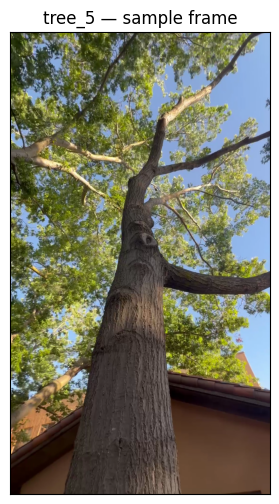

In [5]:
import cv2
from src import viz

if frames:
    sample = cv2.imread(str(frames[len(frames) // 2]))
    fig, ax = plt.subplots(figsize=(6, 6))
    viz.show_image(sample, title=f"{TREE_ID} — sample frame", ax=ax)
    viz.save_fig(fig, f"01_{TREE_ID}_sample_frame.png")
    plt.show()